In [1]:
import numpy as np
import scipy as sp
import qutip as qt
import pandas as pd

np.set_printoptions(precision=4, suppress=True ,linewidth=np.inf, floatmode='fixed')


import matplotlib.pyplot as plt

In [42]:
def get_optimal_unitary(rho_AB, H_A, H_B, tol=1e-9):
    
    if rho_AB is None:
        return np.nan

    dim_A = H_A.shape[0]
    dim_B = H_B.shape[0]
    dim_tot = dim_A * dim_B
    
    I_A = np.eye(dim_A)
    I_B = np.eye(dim_B)
    
    H_tot = np.kron(H_A, I_B) + np.kron(I_A, H_B)
    H_A_tot = np.kron(H_A, I_B) # 전체 공간에서의 H_A 연산자
    
    # 2. 전체 해밀토니안 대각화하여 에너지 고유기저 찾기
    eigvals_tot, eigvecs_tot = np.linalg.eigh(H_tot)
    
    energies_rounded = np.round(eigvals_tot / tol) * tol
    unique_energies = np.unique(energies_rounded)
    
    U_opt = np.zeros((dim_tot, dim_tot), dtype=complex)
    
    for E in unique_energies:
        # 해당 에너지 E를 가지는 인덱스들 찾기
        indices = np.where(np.abs(energies_rounded - E) < tol)[0]
        
        if len(indices) == 0:
            continue
            
        # 부분공간의 기저 벡터들 (Global Energy Eigenbasis)
        subspace_basis = eigvecs_tot[:, indices] # shape: (dim_tot, block_dim)
        
        rho_block = subspace_basis.conj().T @ rho_AB @ subspace_basis
        
        p_nu, v_rho = np.linalg.eigh(rho_block)
        sorted_p_indices = np.argsort(p_nu)[::-1]
        p_nu_sorted = p_nu[sorted_p_indices]
        v_rho_sorted = v_rho[:, sorted_p_indices]
        
        # |phi_n>: 전체 힐베르트 공간에서 rho의 고유상태들
        phi_n_states = subspace_basis @ v_rho_sorted
        

        H_A_block = subspace_basis.conj().T @ H_A_tot @ subspace_basis
        
        e_A_vals, v_HA = np.linalg.eigh(H_A_block)
        
        sorted_e_indices = np.argsort(e_A_vals) # Default is ascending
        e_A_sorted = e_A_vals[sorted_e_indices]
        v_HA_sorted = v_HA[:, sorted_e_indices]
        
        # |epsilon_n>: 전체 힐베르트 공간에서 정렬된 에너지 기저들
        epsilon_n_states = subspace_basis @ v_HA_sorted
        
        U_sub = epsilon_n_states @ phi_n_states.conj().T
        
        U_opt += U_sub
        
    return U_opt

def partial_trace(rho, dim_A, dim_B, keep='A'):
    reshaped_rho = rho.reshape((dim_A, dim_B, dim_A, dim_B))
    
    if keep == 'A':
        # B 시스템을 Trace out (axis 1과 3을 대각합)
        return np.trace(reshaped_rho, axis1=1, axis2=3)
    elif keep == 'B':
        # A 시스템을 Trace out (axis 0과 2를 대각합)
        return np.trace(reshaped_rho, axis1=0, axis2=2)
    else:
        raise ValueError("keep 매라미터는 'A' 또는 'B'여야 합니다.")
    
    
def von_neumann_entropy(rho):
    eigvals = np.linalg.eigvalsh(rho)
    eigvals = eigvals[eigvals > 1e-12]
    return -np.sum(eigvals * np.log(eigvals))
    

def Mutual_infor(rho, omeg, unit, select):
    rho_AB = rho

    if rho_AB is None:
        return np.nan

    omega = omeg
    Unitary = unit
    
    if select == 0:
        state_total = np.kron(rho_AB, omega)
        state_evolve = Unitary @ state_total @ Unitary.conj().T

        S_AB    = von_neumann_entropy(partial_trace(state_evolve, 4, 3, 'A'))  # AB만
        S_C     = von_neumann_entropy(partial_trace(state_evolve, 4, 3, 'B'))  # C만
        S_total = von_neumann_entropy(state_evolve)                             # 전체

        mutual_info = S_AB + S_C - S_total

    elif select == 1:
        state_evolve = Unitary @ rho_AB @ Unitary.conj().T
        S_A    = von_neumann_entropy(partial_trace(state_evolve,2,2,'A'))
        S_B    = von_neumann_entropy(partial_trace(state_evolve,2,2,'B'))
        S_total = von_neumann_entropy(state_evolve)
        
        mutual_info = S_A + S_B - S_total
    
    else:
        S_A    = von_neumann_entropy(partial_trace(rho_AB,2,2,'A'))
        S_B    = von_neumann_entropy(partial_trace(rho_AB,2,2,'B'))
        S_total = von_neumann_entropy(rho_AB)
        
        mutual_info = S_A + S_B - S_total

    return mutual_info


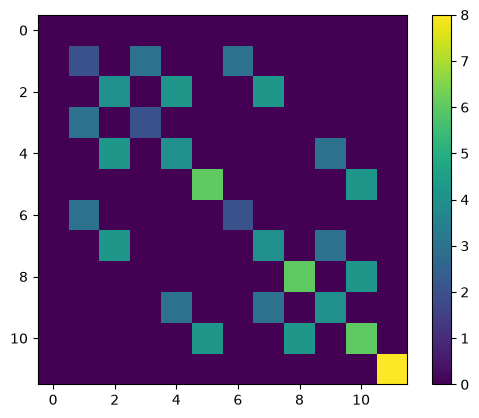

In [9]:
lamb = np.linspace(0,1,50)
theta = np.linspace(0,1,50)
# lamb + theta =< 1

eps = 2
g = 3
beta_a = 2
beta_b = 1
beta = 1.5
t = np.linspace(0,1,1000)

# === 기본 연산자 정의 ===
# 큐비트 (2준위)
I2 = np.eye(2)
sigma_dag = np.array([[0, 0], [1, 0]])   # σ† (raising)
sigma     = np.array([[0, 1], [0, 0]])   # σ  (lowering)
n_q       = sigma_dag @ sigma            # σ†σ (number operator for qubit)

# 캐비티 (N=3 Fock)
N = 3
I3 = np.eye(N)
a_dag = np.diag(np.sqrt(np.arange(1, N)), k=-1)   # a† (creation)
a     = np.diag(np.sqrt(np.arange(1, N)), k=+1)   # a  (annihilation)
n_c   = a_dag @ a                                  # a†a (photon number)


# === 전체 공간 임베딩: A ⊗ B ⊗ C ===
def embed(op, site, dims=(2, 2, N)):
    """site번째 서브시스템에만 op를 작용, 나머지는 Identity"""
    ops = [np.eye(d) for d in dims]
    ops[site] = op
    result = ops[0]
    for o in ops[1:]:
        result = np.kron(result, o)
    return result

# 각 서브시스템의 number operator
n_A = embed(n_q, site=0)
n_B = embed(n_q, site=1)
n_C = embed(n_c, site=2)

# 자유 해밀토니안 H0 = ε(σ†_A σ_A + σ†_B σ_B + a†a)
H0 = eps * (n_A + n_B + n_C)

# 상호작용 H_int = g Σ_{i=A,B} (a σ†_i + a† σ_i)
H_int = g * (
    embed(sigma_dag, 0) @ embed(a,     2) +   # a  σ†_A
    embed(sigma,     0) @ embed(a_dag, 2) +   # a† σ_A
    embed(sigma_dag, 1) @ embed(a,     2) +   # a  σ†_B
    embed(sigma,     1) @ embed(a_dag, 2)     # a† σ_B
)

# 최종 해밀토니안
Ham = H0 + H_int

plt.imshow(Ham)
plt.colorbar()

In [10]:
ket_phi_plus = qt.bell_state('00') # (|00> + |11>) / sqrt(2)
ket_psi_minus = qt.bell_state('11') # (|01> - |10>) / sqrt(2)

dm_phi_plus = qt.ket2dm(ket_phi_plus)
dm_psi_minus = qt.ket2dm(ket_psi_minus)

np_phi_plu = dm_phi_plus.full()
np_psi_min = dm_psi_minus.full()

def Gibb(beta,mat):
    Gib = sp.linalg.expm(-beta * mat)
    Part_func = np.trace(Gib)

    return Gib/Part_func

H_spin = eps * n_q

gamma_A = Gibb(beta_a, H_spin)   # 2×2
gamma_B = Gibb(beta_b, H_spin)   # 2×2

def Cal_rho(lamb_index, theta_index):
    lam = lamb[lamb_index]
    the = theta[theta_index]
    if lam + the > 1.0:
        return None          # 히트맵에서 nan 처리용
    rho = (1 - lam - the) * np.kron(gamma_A, gamma_B) \
        + lam * np_phi_plu \
        + the * np_psi_min
    return rho

In [11]:
def Delta_E_Star(rhoAB):
    rho = rhoAB
    if rho is None:
        return np.nan
    
    opt_unit = get_optimal_unitary(rho,H_spin,H_spin)

    sig_A = partial_trace(opt_unit @ rho @ opt_unit.conj().T,2,2,'A')
    Esig_A = np.trace(H_spin @ sig_A)

    rho_A = partial_trace(rho,2,2,'A')
    Erho_A = np.trace(H_spin @ rho_A).real

    return Esig_A - Erho_A

/var/folders/qj/rtd4hgd952x_ggtxyc1fjx1r0000gn/T/ipykernel_77489/4112051413.py:12: ComplexWarning: Casting complex values to real discards the imaginary part
  heatmap_data[theta_idx, lamb_idx] = val


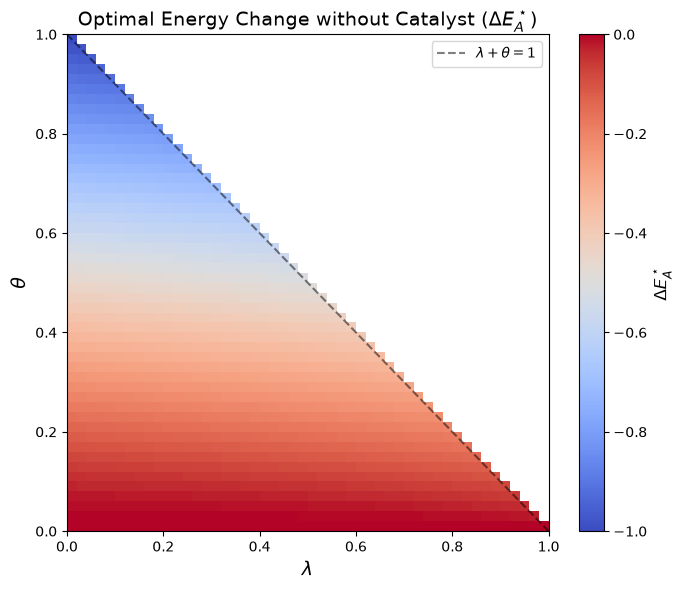

In [43]:
n_pts = 50
heatmap_data = np.zeros((n_pts, n_pts))
heatmap_data0 = np.zeros((n_pts, n_pts))
heatmap_data1 = np.zeros((n_pts,n_pts))

# 반복문을 돌면서 데이터 채우기
# # 행(row)은 y축인 theta, 열(col)은 x축인 lambda에 대응됩니다.
for theta_idx in range(n_pts):
    for lamb_idx in range(n_pts):
        rhorho = Cal_rho(lamb_idx,theta_idx)
        val = Delta_E_Star(rhorho)
        heatmap_data[theta_idx, lamb_idx] = val
        
        val2 = Mutual_infor(rhorho,np.zeros((2,2)),get_optimal_unitary(rhorho,H_spin,H_spin),1)
        heatmap_data0[theta_idx, lamb_idx] = val2    
        
        val3 = Mutual_infor(rhorho,np.zeros((2,2)),get_optimal_unitary(rhorho,H_spin,H_spin),2)
        heatmap_data1[theta_idx, lamb_idx] = val3 
        

plt.figure(figsize=(7, 6))

# imshow로 히트맵 그리기 (origin='lower'로 설정해야 y축이 아래에서 위로 올라갑니다)
# cmap은 파란색-빨간색 대비가 잘 보이는 'coolwarm' 등을 쓰면 좋습니다.
im = plt.imshow(heatmap_data, origin='lower', extent=[0, 1, 0, 1], 
                cmap='coolwarm', aspect='auto')

# 컬러바 추가
cbar = plt.colorbar(im)
cbar.set_label(r'$\Delta E_A^\star$', fontsize=12)

# 축 라벨 및 타이틀
plt.xlabel(r'$\lambda$', fontsize=14)
plt.ylabel(r'$\theta$', fontsize=14)
plt.title(r'Optimal Energy Change without Catalyst ($\Delta E_A^\star$)', fontsize=14)

# 물리적 한계선 (lambda + theta = 1) 가이드라인 그리기
plt.plot([0, 1], [1, 0], 'k--', alpha=0.5, label=r'$\lambda + \theta = 1$')
plt.legend()

plt.tight_layout()
plt.show()

In [39]:
heatmap_data0[0]

array([0.0000, 0.0093, 0.0251, 0.0431, 0.0625, 0.0826, 0.1034, 0.1245, 0.1460, 0.1678, 0.1899, 0.2122, 0.2347, 0.2574, 0.2803, 0.3034, 0.3267, 0.3502, 0.3739, 0.3979, 0.4220, 0.4463, 0.4709, 0.4958, 0.5209, 0.5463, 0.5720, 0.5980, 0.6244, 0.6511, 0.6782, 0.7057, 0.7337, 0.7622, 0.7912, 0.8208, 0.8511, 0.8821, 0.9138, 0.9465, 0.9801, 1.0148, 1.0509, 1.0884, 1.1277, 1.1693, 1.2136, 1.2618, 1.3160, 1.3863])

In [13]:
def Unitary(tau):
    return sp.linalg.expm(-1j * Ham * tau)


def get_omega_C(rho_AB, unit, n_iter=1000, tol=1e-10):
    
    U = unit
        
    if rho_AB is None:
        return np.nan
    
    # 초기값: 진공 상태 |0><0|
    omega_C = np.zeros((N, N), dtype=complex)
    omega_C[0, 0] = 1.0
    
    for _ in range(n_iter):
        # 채널 E(omega_C) = Tr_AB[U (rho_AB ⊗ omega_C) U†]
        rho_full = np.kron(rho_AB, omega_C)           # 4N × 4N
        evolved = U @ rho_full @ U.conj().T
        omega_new = partial_trace(evolved, 4, N, 'B') # AB를 trace out
        
        # 수렴 확인
        if np.linalg.norm(omega_new - omega_C) < tol:
            break
        omega_C = omega_new
    
    return omega_C

def get_omega_C_symmetric(rho_AB, unit, n_iter=500, tol=1e-10):
    """Fixed point를 찾되, 매 iteration마다 diagonal만 유지 (symmetric 강제)"""
    
    U = unit
    
    if rho_AB is None:
        return np.nan
        
    omega_C = np.zeros((N, N), dtype=complex)
    omega_C[0, 0] = 1.0
    
    for _ in range(n_iter):
        rho_full = np.kron(rho_AB, omega_C)
        evolved = U @ rho_full @ U.conj().T
        omega_new = partial_trace(evolved, 4, N, 'B')
        
        # ← 핵심: off-diagonal 강제 제거 (Symmetric 제약)
        omega_new = np.diag(np.diag(omega_new).real)
        omega_new = omega_new / np.trace(omega_new)  # 정규화
        
        if np.linalg.norm(omega_new - omega_C) < tol:
            break
        omega_C = omega_new
    
    return omega_C


def Delta_E(rho, omeg, unit):
    rho_AB = rho

    if rho_AB is None:
        return np.nan
    
    omega = omeg  # State of Omega_C , 임의의 상태로 받을 수 있게 수정
    
    state_total = np.kron(rho_AB, omega)
    state_evolve = unit @ state_total @ unit.conj().T

    sigma_prime_AB = partial_trace(state_evolve,4,3,'A')  

    opt_unit = get_optimal_unitary(sigma_prime_AB, H_spin, H_spin)  
    sigma_opt_prime_AB = opt_unit @ sigma_prime_AB @ opt_unit.conj().T

    sigma_prime_A = partial_trace(sigma_opt_prime_AB, 2, 2, 'A')
    Esig_prime_A = np.trace(H_spin @ sigma_prime_A).real

    rho_A = partial_trace(rho_AB, 2, 2, 'A')
    Erho_A = np.trace(H_spin @ rho_A).real

    return Esig_prime_A - Erho_A

In [14]:
rhorho = Cal_rho(49,0)
Unitary_mat = Unitary(t[-1])
omeg_c = get_omega_C(rhorho,Unitary_mat)

omeg_c

array([[0.6482-0.0000j, 0.0000+0.0000j, 0.0311+0.0169j],
       [0.0000+0.0000j, 0.2656-0.0000j, 0.0000+0.0000j],
       [0.0311-0.0169j, 0.0000+0.0000j, 0.0863+0.0000j]])

In [30]:
n_pts = 50
heatmap_data2 = np.zeros((n_pts, n_pts))
heatmap_data3 = np.zeros((n_pts, n_pts))

Unitary_mat = Unitary(t[-1])

# 반복문을 돌면서 데이터 채우기
# # 행(row)은 y축인 theta, 열(col)은 x축인 lambda에 대응됩니다.
for theta_idx in range(n_pts):
    for lamb_idx in range(n_pts):
        # lambda, theta에 따른 rho, 최적 omega 계산
        rhorho = Cal_rho(lamb_idx,theta_idx)
        omeg_c = get_omega_C(rhorho,Unitary_mat) # 임의의 omega를 집어넣어도 됨
        print(rhorho,omeg_c)
        
        # heatmap 제작을 위한 Deleta_E값 계산
        val = Delta_E(rhorho,omeg_c,Unitary_mat)
        heatmap_data2[theta_idx, lamb_idx] = val

        #mutual information 계산을 위한 for loop
        val2 =Mutual_infor(rhorho, omeg_c, Unitary_mat, 0)
        heatmap_data3[theta_idx, lamb_idx] = val2

[[0.8650+0.0000j 0.0000+0.0000j 0.0000+0.0000j 0.0000+0.0000j]
 [0.0000+0.0000j 0.1171+0.0000j 0.0000+0.0000j 0.0000+0.0000j]
 [0.0000+0.0000j 0.0000+0.0000j 0.0158+0.0000j 0.0000+0.0000j]
 [0.0000+0.0000j 0.0000+0.0000j 0.0000+0.0000j 0.0021+0.0000j]] [[0.9251-0.0000j 0.0000+0.0000j 0.0000+0.0000j]
 [0.0000+0.0000j 0.0699+0.0000j 0.0000+0.0000j]
 [0.0000+0.0000j 0.0000+0.0000j 0.0050-0.0000j]]
[[0.8575+0.0000j 0.0000+0.0000j 0.0000+0.0000j 0.0102+0.0000j]
 [0.0000+0.0000j 0.1147+0.0000j 0.0000+0.0000j 0.0000+0.0000j]
 [0.0000+0.0000j 0.0000+0.0000j 0.0155+0.0000j 0.0000+0.0000j]
 [0.0102+0.0000j 0.0000+0.0000j 0.0000+0.0000j 0.0123+0.0000j]] [[0.9207-0.0000j 0.0000+0.0000j 0.0012+0.0007j]
 [0.0000+0.0000j 0.0729-0.0000j 0.0000+0.0000j]
 [0.0012-0.0007j 0.0000+0.0000j 0.0064+0.0000j]]
[[0.8501+0.0000j 0.0000+0.0000j 0.0000+0.0000j 0.0204+0.0000j]
 [0.0000+0.0000j 0.1123+0.0000j 0.0000+0.0000j 0.0000+0.0000j]
 [0.0000+0.0000j 0.0000+0.0000j 0.0152+0.0000j 0.0000+0.0000j]
 [0.0204+0.0000

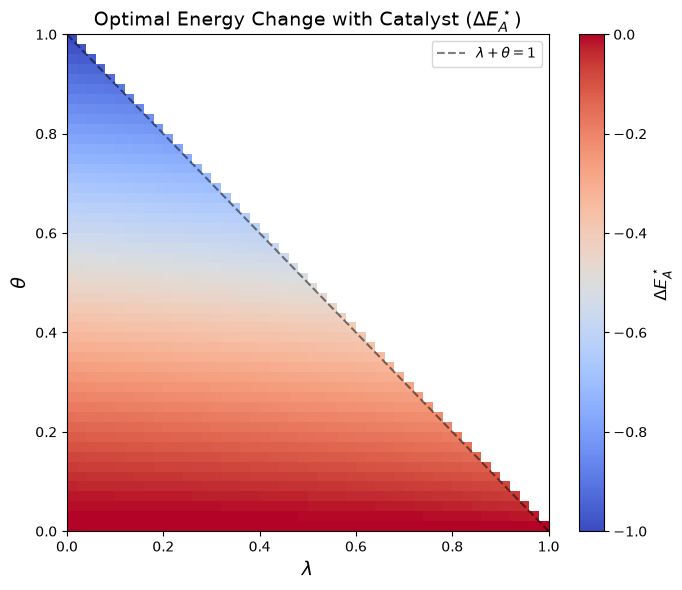

In [16]:
plt.figure(figsize=(7, 6))

# imshow로 히트맵 그리기 (origin='lower'로 설정해야 y축이 아래에서 위로 올라갑니다)
# cmap은 파란색-빨간색 대비가 잘 보이는 'coolwarm' 등을 쓰면 좋습니다.
im = plt.imshow(heatmap_data, origin='lower', extent=[0, 1, 0, 1], 
                cmap='coolwarm', aspect='auto')

# 컬러바 추가
cbar = plt.colorbar(im)
cbar.set_label(r'$\Delta E_A^\star$', fontsize=12)

# 축 라벨 및 타이틀
plt.xlabel(r'$\lambda$', fontsize=14)
plt.ylabel(r'$\theta$', fontsize=14)
plt.title(r'Optimal Energy Change with Catalyst ($\Delta E_A^\star$)', fontsize=14)

# 물리적 한계선 (lambda + theta = 1) 가이드라인 그리기
plt.plot([0, 1], [1, 0], 'k--', alpha=0.5, label=r'$\lambda + \theta = 1$')
plt.legend()

plt.tight_layout()
plt.show()

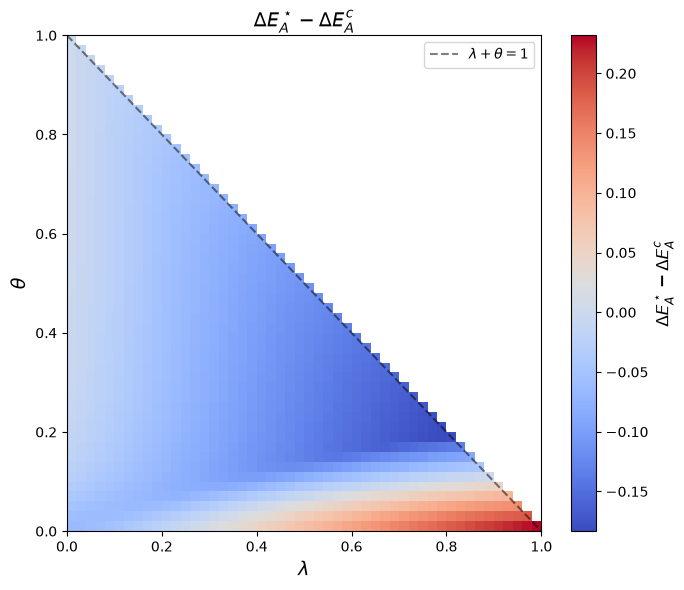

In [17]:
diff_data = heatmap_data - heatmap_data2
plt.figure(figsize=(7, 6))

im = plt.imshow(diff_data, origin='lower', extent=[0, 1, 0, 1],
                cmap='coolwarm', aspect='auto')

cbar = plt.colorbar(im)
cbar.set_label(r'$\Delta E_A^\star - \Delta E_A^c$', fontsize=12)

plt.xlabel(r'$\lambda$', fontsize=14)
plt.ylabel(r'$\theta$', fontsize=14)
plt.title(r'$\Delta E_A^\star - \Delta E_A^c$', fontsize=14)

plt.plot([0, 1], [1, 0], 'k--', alpha=0.5, label=r'$\lambda + \theta = 1$')
plt.legend()

plt.tight_layout()
plt.show()

In [44]:
#np.savetxt("heatmap_data.txt",heatmap_data, delimiter = ",")
np.savetxt("heatmap_data1.txt", heatmap_data1, delimiter = ",")
#np.savetxt("heatmap_data0.txt", heatmap_data0, delimiter=',')
#np.savetxt("heatmap_data2.txt", heatmap_data2, delimiter=",")
#np.savetxt("heatmap_data3.txt", heatmap_data3, delimiter=",")

In [ ]:
-0.1397